In [ ]:
import numpy as np

X_train = np.load('/content/drive/MyDrive/1. Natural Language Processsing/Khóa luận tốt nghiệp/Word2vec/English/training.npy')
y_train = np.load('/content/drive/MyDrive/1. Natural Language Processsing/Khóa luận tốt nghiệp/Word2vec/English/training_labels.npy')
X_test = np.load('/content/drive/MyDrive/1. Natural Language Processsing/Khóa luận tốt nghiệp/Word2vec/English/test.npy')
y_test = np.load('/content/drive/MyDrive/1. Natural Language Processsing/Khóa luận tốt nghiệp/Word2vec/English/test_labels.npy')
embedding_matrix = np.load('/content/drive/MyDrive/1. Natural Language Processsing/Khóa luận tốt nghiệp/Word2vec/English/embedding_matrix.npy')

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Bidirectional, Dense, Embedding, LSTM, Dropout, Conv1D, Layer, MultiHeadAttention
from tensorflow.keras.layers import LayerNormalization, GlobalAveragePooling1D, Input
from tensorflow.keras.callbacks import EarlyStopping

vocab_size = 52145

# embedding = Embedding(vocab_size,
#                       output_dim=int(3e2),
#                       weights=[embedding_matrix],
#                       trainable=True)

class TransformerBlock(Layer):
    def __init__(self, embed_dim, num_heads, rate=0.25):
        super(TransformerBlock, self).__init__()
        self.att = MultiHeadAttention(num_heads=num_heads,
                                      key_dim=embed_dim)
        self.ffn = Sequential([
            Conv1D(embed_dim, kernel_size=5, padding='same'),
            Dense(embed_dim, activation="relu"),
            Dense(embed_dim),
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-7)
        self.layernorm2 = LayerNormalization(epsilon=1e-7)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training):
        attn_output = self.att(inputs, inputs)  # self-attention layer
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)  # layer norm
        ffn_output = self.ffn(out1)  #feed-forward layer
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)  # layer norm

class TokenAndPositionEmbedding(Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super(TokenAndPositionEmbedding, self).__init__()
        self.token_emb = Embedding(input_dim=vocab_size,
                                   weights=[embedding_matrix],
                                   output_dim=embed_dim,
                                   trainable=True)
        self.pos_emb = Embedding(input_dim=vocab_size,  # vocab size, including the 0-th word used for padding
                                 weights=[embedding_matrix],
                                 output_dim=embed_dim,
                                 trainable=True)

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

In [ ]:
embed_dim = 300  # Embedding size for each token
num_heads = 3  # Number of attention heads
maxlen = 300
vocab_size = 52145

model = Sequential()
model.add(Input(shape=(maxlen, )))
model.add(TokenAndPositionEmbedding(maxlen, vocab_size, embed_dim))
model.add(TransformerBlock(embed_dim, num_heads))
model.add(GlobalAveragePooling1D())
model.add(Dropout(0.25))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              metrics=['accuracy'])

model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 token_and_position_embeddi  (None, 300, 300)          31287000  
 ng_1 (TokenAndPositionEmbe                                      
 dding)                                                          
                                                                 
 transformer_block_1 (Trans  (None, 300, 300)          1715100   
 formerBlock)                                                    
                                                                 
 global_average_pooling1d_1  (None, 300)               0         
  (GlobalAveragePooling1D)                                       
                                                                 
 dropout_6 (Dropout)         (None, 300)               0         
                                                                 
 dense_6 (Dense)             (None, 128)              

In [ ]:
callbacks = EarlyStopping(monitor='val_loss', min_delta=1e-3, patience=3)
history = model.fit(X_train, y_train,
                    batch_size=1024,
                    epochs=100,
                    verbose=1,
                    validation_split=0.1,)
                    # callbacks= callbacks)

Epoch 1/100
22/22 [==============================] - 51s 2s/step - loss: 0.7093 - accuracy: 0.5237 - val_loss: 0.8497 - val_accuracy: 0.0000e+00
Epoch 2/100
22/22 [==============================] - 47s 2s/step - loss: 0.6968 - accuracy: 0.5420 - val_loss: 0.7827 - val_accuracy: 0.0060
Epoch 3/100
22/22 [==============================] - 49s 2s/step - loss: 0.6895 - accuracy: 0.5458 - val_loss: 0.8451 - val_accuracy: 0.0028
Epoch 4/100
22/22 [==============================] - 50s 2s/step - loss: 0.6864 - accuracy: 0.5562 - val_loss: 0.8209 - val_accuracy: 0.0164
Epoch 5/100
22/22 [==============================] - 50s 2s/step - loss: 0.6769 - accuracy: 0.5753 - val_loss: 0.8091 - val_accuracy: 0.0476
Epoch 6/100
22/22 [==============================] - 51s 2s/step - loss: 0.6703 - accuracy: 0.5821 - val_loss: 0.8378 - val_accuracy: 0.0580
Epoch 7/100
22/22 [==============================] - 50s 2s/step - loss: 0.6622 - accuracy: 0.6020 - val_loss: 0.8145 - val_accuracy: 0.1100
Epoch 8/1

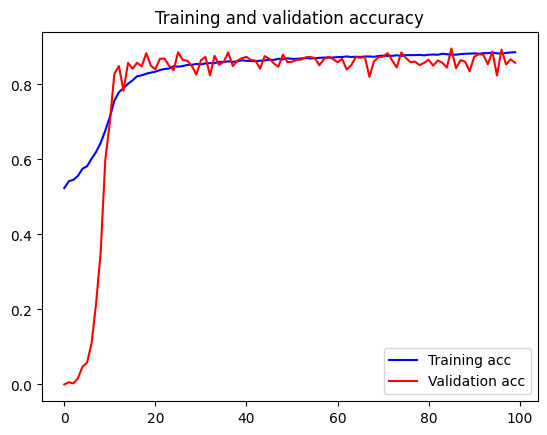

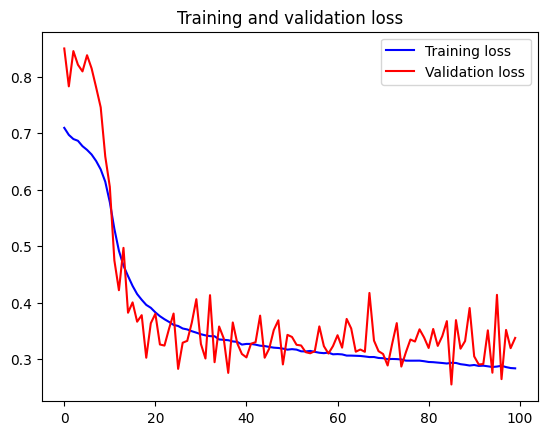

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [ ]:
score = model.evaluate(X_test, y_test, batch_size=1024)
print()
print("ACCURACY:",score[1])
print("LOSS:",score[0])

25/25 [==============================] - 18s 710ms/step - loss: 0.3079 - accuracy: 0.8713

ACCURACY: 0.8712748289108276
LOSS: 0.30788612365722656
